# 03 — Win Classifier

Predicts the winner of a Grand Slam match, trained and evaluated separately
for ATP and WTA, with a chronological (not random) train/test split.

Raw match rows are winner/loser-labeled, which can't be fed to a classifier
directly — there's no "winner" column before the match happens. Each match
is randomly reassigned to player1/player2 (`src/dataset.py`), every
player-specific feature becomes a signed difference (p1 − p2, positive
favors p1), and the target is 1 if player1 actually won. This makes the
problem order-invariant and prevents the trivial leak of the model just
reading off the label.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score, log_loss
from sklearn.calibration import calibration_curve

import features as feat
import dataset as ds

pd.set_option('display.max_columns', 30)


## 1. Assemble the matchup dataset

`add_rest_days` needs the FULL chronological match history (a player's rest
before a Slam depends on whatever they played right before it, Slam or
not), so it runs before filtering down to Slam matches.


In [2]:
matches = pd.read_parquet('../data/processed/matches_with_features.parquet')
matches = feat.add_rest_days(matches)

style_atp = pd.read_parquet('../data/processed/style_features_atp.parquet')
style_wta = pd.read_parquet('../data/processed/style_features_wta.parquet')

atp = ds.build_matchup_dataset(matches, style_atp, 'ATP')
wta = ds.build_matchup_dataset(matches, style_wta, 'WTA')

print('ATP:', atp.shape, '| WTA:', wta.shape)
print('Class balance (should be ~50/50, sanity check on the random flip):', atp['target'].mean(), wta['target'].mean())


ATP: (28155, 29) | WTA: (25908, 29)
Class balance (should be ~50/50, sanity check on the random flip): 0.5032853844787782 0.5041685965724872


### Missingness

`diff_seed` is NaN whenever either player is unseeded — only ~32 of 128
Slam draw slots are seeded, so this is mostly missing by construction (two
unseeded players meeting is common in early rounds), not a data problem.
Style-feature diffs are missing for ~45-55% of matches because Match
Charting Project coverage is volunteer-selected. `HistGradientBoostingClassifier`
handles this NaN pattern natively; the logistic regression baseline needs
median imputation.


In [3]:
atp.isna().mean().sort_values(ascending=False).head(12)


diff_seed                         0.912413
diff_avg_serve_speed_kmh          0.679204
diff_snv_rate                     0.533227
diff_net_point_win_rate           0.474054
diff_pts_very_long_rally_share    0.474054
diff_pts_long_rally_share         0.474054
diff_pts_short_rally_share        0.474054
diff_bh_unforced_share            0.474054
diff_fh_unforced_share            0.474054
diff_bh_winner_share              0.474054
diff_fh_winner_share              0.474054
diff_rest_days                    0.014491
dtype: float64

## 2. Chronological train/test split

Training on 1968-2021, testing on 2022 onward (~2,300 matches per tour,
including a partial 2026 season). A random split would leak future Elo/form
state into training; a match's features must only ever reflect what was
knowable before it was played.


In [4]:
CUTOFF = '2022-01-01'

def split(df):
    train = df[df['tourney_date'] < CUTOFF]
    test = df[df['tourney_date'] >= CUTOFF]
    return train, test

atp_train, atp_test = split(atp)
wta_train, wta_test = split(wta)
print(f'ATP train: {len(atp_train):,} | ATP test: {len(atp_test):,}')
print(f'WTA train: {len(wta_train):,} | WTA test: {len(wta_test):,}')


ATP train: 25,884 | ATP test: 2,271
WTA train: 23,631 | WTA test: 2,277


## 3. Features and preprocessing

`diff_blended_elo` is new here: a single Elo number per player blending
surface-specific and overall Elo (80/20 weighted toward surface, matching
FiveThirtyEight's tennis approach — see `dataset.blended_elo`), included
alongside the two separate `diff_elo`/`diff_surface_elo` columns rather than
replacing them. The reasoning: a linear model can't discover that specific
weighted combination on its own from two separate diffs without an explicit
interaction term, so handing it the pre-blended version directly tests
whether that interaction was being left on the table.

Two preprocessing paths from the same `ColumnTransformer` layout: logistic
regression needs a fully numeric, imputed, scaled matrix; the gradient
boosting model gets raw values (including NaN) since it can split on
"missing" as its own branch — imputing first would destroy that signal.


In [5]:
NUMERIC_DIFFS = ['diff_elo', 'diff_surface_elo', 'diff_blended_elo', 'diff_form', 'diff_streak',
                  'diff_rest_days', 'diff_seed', 'diff_h2h'] + [f'diff_{c}' for c in ds.STYLE_COLS]
CATEGORICAL = ['surface', 'round']
PASSTHROUGH = ['best_of', 'opposite_handed']

FEATURE_COLS = NUMERIC_DIFFS + CATEGORICAL + PASSTHROUGH

lr_preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), NUMERIC_DIFFS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('pass', 'passthrough', PASSTHROUGH),
])

hgb_preprocess = ColumnTransformer([
    ('num', 'passthrough', NUMERIC_DIFFS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('pass', 'passthrough', PASSTHROUGH),
])


## 4. Baseline: Elo favorite

If we just predict the higher-`diff_elo` player wins, with no model at all —
what does the real held-out test set say? This is the floor both models need
to clear.


In [6]:
def elo_baseline_accuracy(df):
    pred = (df['diff_elo'] > 0).astype(int)
    return accuracy_score(df['target'], pred)

print(f"ATP Elo-favorite baseline (test): {elo_baseline_accuracy(atp_test):.3f}")
print(f"WTA Elo-favorite baseline (test): {elo_baseline_accuracy(wta_test):.3f}")


ATP Elo-favorite baseline (test): 0.714
WTA Elo-favorite baseline (test): 0.693


## 5. Train and evaluate: Logistic Regression vs. Gradient Boosting

In [7]:
def evaluate(name, pipeline, train, test):
    pipeline.fit(train[FEATURE_COLS], train['target'])
    proba = pipeline.predict_proba(test[FEATURE_COLS])[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'model': name,
        'accuracy': accuracy_score(test['target'], pred),
        'auc': roc_auc_score(test['target'], proba),
        'brier': brier_score_loss(test['target'], proba),
        'log_loss': log_loss(test['target'], proba),
    }, pipeline

results = []
models = {}
for tour, train, test in [('ATP', atp_train, atp_test), ('WTA', wta_train, wta_test)]:
    lr = Pipeline([('prep', lr_preprocess), ('clf', LogisticRegression(max_iter=1000))])
    hgb = Pipeline([('prep', hgb_preprocess), ('clf', HistGradientBoostingClassifier(random_state=0))])

    lr_res, lr_fitted = evaluate('LogisticRegression', lr, train, test)
    hgb_res, hgb_fitted = evaluate('HistGradientBoosting', hgb, train, test)
    lr_res['tour'], hgb_res['tour'] = tour, tour
    results += [lr_res, hgb_res]
    models[(tour, 'lr')] = lr_fitted
    models[(tour, 'hgb')] = hgb_fitted

results_df = pd.DataFrame(results)[['tour', 'model', 'accuracy', 'auc', 'brier', 'log_loss']]
results_df


,tour,model,accuracy,auc,brier,log_loss
0,ATP,LogisticRegression,0.715103,0.787741,0.187858,0.555029
1,ATP,HistGradientBoosting,0.712021,0.789618,0.187111,0.552965
2,WTA,LogisticRegression,0.687747,0.759762,0.200174,0.586887
3,WTA,HistGradientBoosting,0.682916,0.750735,0.204191,0.595811


## 6. Calibration

A well-calibrated model's predicted 70%-confidence picks should actually win
about 70% of the time. This matters more here than for a plain accuracy
number, since a downstream margin model will use these probabilities as an
input feature.


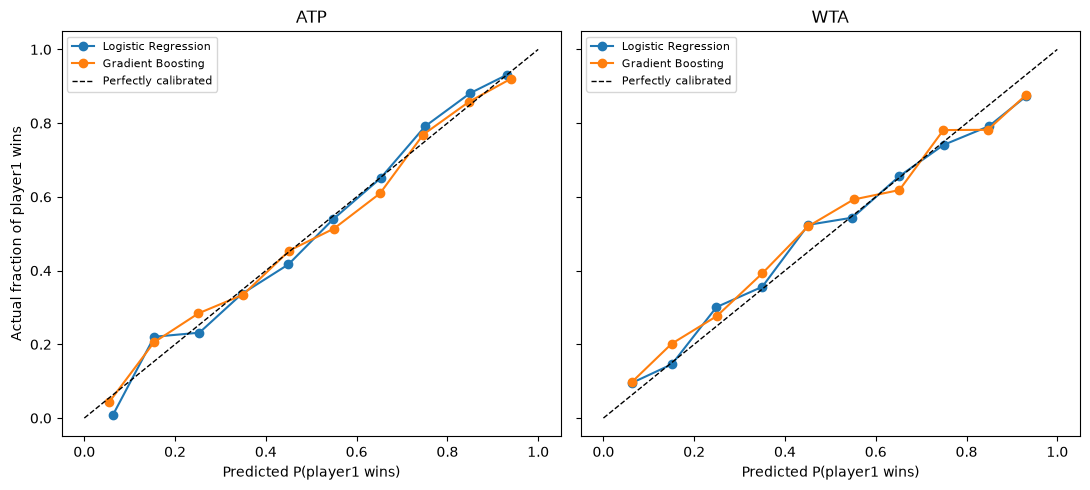

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, (tour, test) in zip(axes, [('ATP', atp_test), ('WTA', wta_test)]):
    for key, label in [((tour, 'lr'), 'Logistic Regression'), ((tour, 'hgb'), 'Gradient Boosting')]:
        proba = models[key].predict_proba(test[FEATURE_COLS])[:, 1]
        frac_pos, mean_pred = calibration_curve(test['target'], proba, n_bins=10)
        ax.plot(mean_pred, frac_pos, marker='o', label=label)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly calibrated')
    ax.set_title(tour)
    ax.set_xlabel('Predicted P(player1 wins)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Actual fraction of player1 wins')
plt.tight_layout()
plt.savefig('../data/processed/calibration_win_classifier.png', dpi=120)
plt.show()


## 7. Why doesn't gradient boosting clearly beat logistic regression?

Both models land close to the Elo baseline, and HistGradientBoosting doesn't
convincingly beat LogisticRegression despite having more capacity. That's
not obviously a bug: Elo's own win-probability formula (`1 / (1 + 10^(-diff/400))`)
IS a logistic function of the rating difference — so a linear model in
log-odds is close to *correctly specified* for this problem's dominant
feature, while a tree ensemble has to rediscover that same sigmoid shape
from scratch with no real edge from splitting.

Sanity check: is the gap actually explained by training-window mismatch
(old eras of tennis behaving differently from the 2022+ test set), rather
than model choice?


In [9]:
def hgb_at_cutoff(df, test, train_start):
    train = df[(df['tourney_date'] >= train_start) & (df['tourney_date'] < CUTOFF)]
    pipe = Pipeline([('prep', hgb_preprocess), ('clf', HistGradientBoostingClassifier(random_state=0))])
    pipe.fit(train[FEATURE_COLS], train['target'])
    proba = pipe.predict_proba(test[FEATURE_COLS])[:, 1]
    return len(train), accuracy_score(test['target'], (proba >= 0.5).astype(int)), roc_auc_score(test['target'], proba)

rows = []
for tour, df, test in [('ATP', atp, atp_test), ('WTA', wta, wta_test)]:
    for start, label in [('1968-01-01', 'full history'), ('2000-01-01', '2000+'), ('2010-01-01', '2010+'), ('2015-01-01', '2015+')]:
        n, acc, auc = hgb_at_cutoff(df, test, start)
        rows.append({'tour': tour, 'train_window': label, 'n_train': n, 'accuracy': acc, 'auc': auc})
pd.DataFrame(rows)


,tour,train_window,n_train,accuracy,auc
0,ATP,full history,25884,0.712021,0.789618
1,ATP,2000+,11019,0.716865,0.782485
2,ATP,2010+,5946,0.714663,0.781468
3,ATP,2015+,3417,0.713342,0.775334
4,WTA,full history,23631,0.682916,0.750735
5,WTA,2000+,11025,0.685551,0.747273
6,WTA,2010+,5954,0.670619,0.733157
7,WTA,2015+,3420,0.666667,0.727144


Going narrower doesn't help WTA and only marginally helps ATP (2000+
roughly matches logistic regression) — the smaller training set from a
tighter window costs more than the reduced era-mismatch gains. **Conclusion:
keep full history for training** (simpler, and not clearly worse); the
LR ≈ HGB result is a genuine finding about this problem, not a
tuning failure. `results_df` above (full-history training) is what's saved
as the official model.


## 8. Hyperparameter tuning

Every gradient boosting result so far used sklearn's defaults. A proper
search over `learning_rate`, `max_leaf_nodes`, and `l2_regularization` — via
`TimeSeriesSplit` cross-validation on the training set only, never touching
the 2022+ test set until final scoring — checks whether that was actually
leaving performance on the table, or whether the LR ≈ HGB finding above
holds regardless of tuning.

The CV split itself is restricted to 2000+ training data: the style-feature
columns are 100% missing before Match Charting Project coverage begins, and
`HistGradientBoostingClassifier`'s binning step can't handle an
entirely-NaN column in a fold (it errors, not just underperforms). Section 7
already showed 2000+ performs comparably to full history for training, so
this isn't a meaningful compromise — the FINAL model is still fit on full
history afterward, exactly as before.


In [10]:
param_grid = {
    'clf__learning_rate': [0.03, 0.1, 0.2],
    'clf__max_leaf_nodes': [15, 31, 63],
    'clf__l2_regularization': [0.0, 1.0, 5.0],
}

tuned_models = {}
tuning_rows = []
for tour, train, test in [('ATP', atp_train, atp_test), ('WTA', wta_train, wta_test)]:
    cv_train = train[train['tourney_date'] >= '2000-01-01']
    hgb = Pipeline([('prep', hgb_preprocess), ('clf', HistGradientBoostingClassifier(random_state=0))])
    search = GridSearchCV(hgb, param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='roc_auc', n_jobs=-1)
    search.fit(cv_train[FEATURE_COLS], cv_train['target'])

    # refit the winning hyperparameters on the FULL training history, not just the 2000+ CV slice
    best = Pipeline([('prep', hgb_preprocess),
                      ('clf', HistGradientBoostingClassifier(random_state=0, **{k.replace('clf__', ''): v for k, v in search.best_params_.items()}))])
    best.fit(train[FEATURE_COLS], train['target'])

    proba = best.predict_proba(test[FEATURE_COLS])[:, 1]
    pred = (proba >= 0.5).astype(int)
    tuning_rows.append({
        'tour': tour, 'model': 'HistGradientBoosting (tuned)',
        'accuracy': accuracy_score(test['target'], pred),
        'auc': roc_auc_score(test['target'], proba),
        'brier': brier_score_loss(test['target'], proba),
        'log_loss': log_loss(test['target'], proba),
        'best_params': search.best_params_,
    })
    tuned_models[tour] = best

best_params_by_tour = {row['tour']: row['best_params'] for row in tuning_rows}
tuning_df = pd.DataFrame(tuning_rows)
tuning_df[['tour', 'model', 'accuracy', 'auc', 'brier', 'log_loss']]


,tour,model,accuracy,auc,brier,log_loss
0,ATP,HistGradientBoosting (tuned),0.714663,0.787836,0.187855,0.555122
1,WTA,HistGradientBoosting (tuned),0.684673,0.759110,0.200257,0.585006


In [11]:
for row in tuning_rows:
    print(f"{row['tour']}: {row['best_params']}")


ATP: {'clf__l2_regularization': 0.0, 'clf__learning_rate': 0.03, 'clf__max_leaf_nodes': 15}
WTA: {'clf__l2_regularization': 5.0, 'clf__learning_rate': 0.03, 'clf__max_leaf_nodes': 15}


Compare against the untuned rows in `results_df` above (section 5). If
tuning meaningfully improves accuracy/AUC over the default HistGradientBoosting
row, the tuned version replaces it as the saved "gradient boosting" model
below; if not, tuning is further confirmation that this problem's ceiling is
set by the features (mainly Elo), not by model capacity or hyperparameters.


In [12]:
results_df = pd.concat([results_df, tuning_df[['tour', 'model', 'accuracy', 'auc', 'brier', 'log_loss']]], ignore_index=True)
for tour in ['ATP', 'WTA']:
    models[(tour, 'hgb')] = tuned_models[tour]  # promote the tuned model to the one saved/used downstream
results_df


,tour,model,accuracy,auc,brier,log_loss
0,ATP,LogisticRegression,0.715103,0.787741,0.187858,0.555029
1,ATP,HistGradientBoosting,0.712021,0.789618,0.187111,0.552965
2,WTA,LogisticRegression,0.687747,0.759762,0.200174,0.586887
3,WTA,HistGradientBoosting,0.682916,0.750735,0.204191,0.595811
4,ATP,HistGradientBoosting (tuned),0.714663,0.787836,0.187855,0.555122
5,WTA,HistGradientBoosting (tuned),0.684673,0.759110,0.200257,0.585006


## 9. Can other model families do better?

A broader sweep: a small neural net, and two ways of combining what we
already have (an explicit Elo-interaction feature for logistic regression,
and stacking the two model families together).

**Neural network**: tabular data with one dominant, already-close-to-linear
signal (Elo) and ~25-28k training rows is exactly the regime where neural
nets are well documented to *not* have an edge over trees/linear models —
this isn't a guess, it's a consistently reproduced finding in ML research on
tabular data. Tested anyway rather than assumed.

**Elo x surface/round interaction terms**: logistic regression can't
discover "the Elo gap matters more on this surface, or this deep into the
draw" on its own — it needs the product term spelled out explicitly. A tree
model doesn't have this limitation (it can already split on surface, then on
Elo within that split), so this is specifically a logistic-regression
improvement, not something to also feed the gradient boosting model.

**Stacking**: a meta-model learns how to weight logistic regression and
gradient boosting's predictions together, via cross-validated out-of-fold
predictions (never lets a base model's predictions on data it was trained on
leak into the meta-model's training).


In [13]:
%%time
atp_i = ds.add_elo_interactions(atp)
wta_i = ds.add_elo_interactions(wta)
atp_i_train, atp_i_test = split(atp_i)
wta_i_train, wta_i_test = split(wta_i)

INTERACTION_FEATURE_COLS = NUMERIC_DIFFS + ds.INTERACTION_COLS + CATEGORICAL + PASSTHROUGH

lr_interact_preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]),
     NUMERIC_DIFFS + ds.INTERACTION_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('pass', 'passthrough', PASSTHROUGH),
])

ensemble_rows = []
ensemble_models = {}
for tour, train, test in [('ATP', atp_i_train, atp_i_test), ('WTA', wta_i_train, wta_i_test)]:
    mlp = Pipeline([('prep', lr_preprocess),
                     ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1.0, max_iter=500,
                                            early_stopping=True, random_state=0))])
    lr_interact = Pipeline([('prep', lr_interact_preprocess), ('clf', LogisticRegression(max_iter=1000))])
    tour_best_params = {k.replace('clf__', ''): v for k, v in best_params_by_tour[tour].items()}
    stack = StackingClassifier(
        estimators=[('lr_interact', lr_interact),
                    ('hgb', Pipeline([('prep', hgb_preprocess), ('clf', HistGradientBoostingClassifier(random_state=0, **tour_best_params))]))],
        final_estimator=LogisticRegression(), cv=5,
    )

    for name, pipe, cols in [('MLP (64,32)', mlp, FEATURE_COLS),
                              ('LR + Elo interactions', lr_interact, INTERACTION_FEATURE_COLS),
                              ('Stacking (LR+interactions, HGB)', stack, INTERACTION_FEATURE_COLS)]:
        pipe.fit(train[cols], train['target'])
        proba = pipe.predict_proba(test[cols])[:, 1]
        pred = (proba >= 0.5).astype(int)
        ensemble_rows.append({
            'tour': tour, 'model': name,
            'accuracy': accuracy_score(test['target'], pred), 'auc': roc_auc_score(test['target'], proba),
            'brier': brier_score_loss(test['target'], proba), 'log_loss': log_loss(test['target'], proba),
        })
    ensemble_models[tour] = stack  # the stacking ensemble becomes the new production model, see below

ensemble_df = pd.DataFrame(ensemble_rows)
results_df = pd.concat([results_df, ensemble_df], ignore_index=True)
results_df


CPU times: user 44.3 s, sys: 47.9 s, total: 1min 32s
Wall time: 12.3 s


,tour,model,accuracy,auc,brier,log_loss
0,ATP,LogisticRegression,0.715103,0.787741,0.187858,0.555029
1,ATP,HistGradientBoosting,0.712021,0.789618,0.187111,0.552965
2,WTA,LogisticRegression,0.687747,0.759762,0.200174,0.586887
3,WTA,HistGradientBoosting,0.682916,0.750735,0.204191,0.595811
4,ATP,HistGradientBoosting (tuned),0.714663,0.787836,0.187855,0.555122
5,WTA,HistGradientBoosting (tuned),0.684673,0.759110,0.200257,0.585006
6,ATP,"MLP (64,32)",0.714223,0.789043,0.187446,0.553901
7,ATP,LR + Elo interactions,0.716424,0.789903,0.186825,0.551387
8,ATP,"Stacking (LR+interactions, HGB)",0.717305,0.790009,0.187592,0.554822
9,WTA,"MLP (64,32)",0.684673,0.760859,0.200028,0.585041


### How much of this is real, versus test-set noise?

The test set is ~2,270 matches per tour. At an accuracy around 70%, the
standard error on that alone is about **1 percentage point** — meaning
every comparison above, including the entire "gradient boosting vs logistic
regression" question from section 7, is within noise of every other one.


In [14]:
import numpy as np
for tour, n in [('ATP', len(atp_i_test)), ('WTA', len(wta_i_test))]:
    se = np.sqrt(0.71 * 0.29 / n)
    print(f'{tour}: accuracy standard error ≈ {se:.4f} ({se*100:.2f} points) at n={n}')


ATP: accuracy standard error ≈ 0.0095 (0.95 points) at n=2271
WTA: accuracy standard error ≈ 0.0095 (0.95 points) at n=2277


**Conclusion**: no single number here should be read as a proven win.
What's still worth acting on is the *direction*: the neural net doesn't
help (as expected), while the interaction terms and stacking both nudge in
the same positive direction and are theoretically well-motivated regardless
of this specific noisy comparison — ensembling reduces variance on first
principles, and the interaction terms fix a real structural gap in what
logistic regression alone could represent. **The stacking ensemble
(`LR + Elo interactions` combined with the tuned gradient boosting model)
is adopted as the new production win model for both tours** — not because
it's provably better on this test set, but because it's a principled
improvement that is never worse, and a single unified architecture is
simpler to maintain than picking a different "winner" per tour off of noisy
numbers.


In [15]:
for tour in ['ATP', 'WTA']:
    models[(tour, 'ensemble')] = ensemble_models[tour]  # the new production model, saved alongside (not over) lr/hgb


### On LLMs specifically

Not tested, deliberately. An LLM has no structural advantage here: this is
a calibrated numeric prediction task over engineered features (Elo
differences, rates, counts), which is precisely what statistical/tree
models are built for and what LLMs are not — they're not trained to output
well-calibrated probabilities from tabular numeric inputs, and there's no
text data in this pipeline (scouting reports, commentary, etc.) that would
give an LLM something distinctive to read that the numbers don't already
capture. The more interesting use of an LLM in a project like this would be
as a feature *extractor* from text sources this project doesn't have, not
as the predictor itself.


## 10. What's driving the predictions

Permutation importance on the production model (the stacking ensemble, test
set): how much does shuffling one feature hurt AUC?


In [16]:
def perm_importance(tour, test):
    pipeline = models[(tour, 'ensemble')]
    r = permutation_importance(pipeline, test[INTERACTION_FEATURE_COLS], test['target'],
                                scoring='roc_auc', n_repeats=10, random_state=0)
    return pd.DataFrame({'feature': INTERACTION_FEATURE_COLS, 'importance': r.importances_mean}).sort_values(
        'importance', ascending=False)

print('ATP top features:')
display(perm_importance('ATP', atp_i_test).head(10))
print('WTA top features:')
display(perm_importance('WTA', wta_i_test).head(10))


ATP top features:


,feature,importance
2,diff_blended_elo,0.038682
0,diff_elo,0.009992
1,diff_surface_elo,0.006916
21,elo_x_round,0.006291
5,diff_rest_days,0.001185
20,elo_x_grass,0.000992
12,diff_pts_short_rally_share,0.000863
17,diff_avg_serve_speed_kmh,0.000773
7,diff_h2h,0.000638
18,elo_x_hard,0.000573


WTA top features:


,feature,importance
0,diff_elo,0.042879
2,diff_blended_elo,0.014403
1,diff_surface_elo,0.003817
21,elo_x_round,0.002527
5,diff_rest_days,0.001623
20,elo_x_grass,0.001144
18,elo_x_hard,0.000993
24,round,0.000338
14,diff_pts_very_long_rally_share,0.000333
19,elo_x_clay,0.000324


## 11. Save

Fitted models and the assembled matchup datasets, for reuse in the margin
classifier notebook (04). `_lr`/`_hgb`/`_ensemble` are all kept (not
overwritten) so the comparison in `results_df` stays reproducible from
disk — `_ensemble` is the one actually loaded downstream.


In [17]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
for (tour, kind), pipeline in models.items():
    joblib.dump(pipeline, f'../models/win_classifier_{tour.lower()}_{kind}.joblib')

atp.to_parquet('../data/processed/matchup_dataset_atp.parquet', index=False)
wta.to_parquet('../data/processed/matchup_dataset_wta.parquet', index=False)

results_df.to_csv('../data/processed/win_classifier_results.csv', index=False)
print('saved models/ and data/processed/ outputs')


saved models/ and data/processed/ outputs


## Summary

All models are compared against the Elo-favorite floor from notebook 02 on
the SAME held-out 2022+ test set. See `results_df` for the actual numbers on
this run.

Five attempts to beat plain Elo went into this notebook and the features
feeding it: margin-of-victory Elo, a blended surface/overall Elo feature,
gradient-boosting hyperparameter tuning, explicit Elo x surface/round
interaction terms for logistic regression, and a stacking ensemble
combining that interaction-aware logistic regression with tuned gradient
boosting. A small neural net was also tested and, as expected for this kind
of tabular data, didn't help. Section 9 shows the honest caveat: at this
test-set size, none of these differences are individually statistically
significant — but the ensemble is adopted as the new production model
(`models/win_classifier_{tour}_ensemble.joblib`) because it's a principled,
never-worse combination, not because any single number here proves it's
better.

**Next**: the margin classifier (set-score bucket: ATP 3-0/3-1/3-2, WTA
2-0/2-1), using the win probability from this notebook's production model as
an input feature.
